# Sunspot detection
In this notebook, we will illustrate how to detect sunspots on a sun image downloaded from the [Bruxelles Observatory](https://www.sidc.be/). We will use the following images:

In [1]:
fits_image_url = "https://www.sidc.be/uset/data/cameras/output_img/FTS/L0/USET_White_Light/2005/10/UPH20051003093417.FTS"
drawing_url = "https://www.sidc.be/uset/data/drawings/2014/06/usd201406090730.jpg"

The first image is a photograph of the sun. The second one is a hand-drawn sketch indicating the sunspots. Such sketches have been used for sunspot documentation before photography, and continue to be produced for continuing the four-century-old time series using the same techniques.

## Document the Python environment

In [2]:
import sys
print("Python version: ", sys.version)
import numpy
print("NumPy version: ", numpy.__version__)
import scipy
print("SciPy version: ", scipy.__version__)
import skimage
print("scikit-image version: ", skimage.__version__)
import fitsio
print("fitsio version: ", fitsio.__version__)

Python version:  3.11.4 | packaged by conda-forge | (main, Jun 10 2023, 18:08:17) [GCC 12.2.0]
NumPy version:  1.24.3
SciPy version:  1.10.1
scikit-image version:  0.20.0
fitsio version:  1.2.1


## Plotting code for later use

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
def show_image(image, name):
    filename = os.path.join('outputs', name + '.png')
    plt.clf()
    plt.imshow(image, cmap='gray', origin='lower')
    plt.colorbar()
    plt.savefig(filename)
    return filename

In [5]:
def intensity_cross_sections(intensities, name, threshold=None):
    filename = os.path.join('outputs', name + '.png')
    plt.clf()
    for i in intensities:
        plt.plot(i, '-')
    if threshold is not None:
        plt.plot([0, max(map(len, intensities))],
                 [threshold, threshold],
                 'k-')
    plt.savefig(filename)
    return filename

## Create the data directories

In [6]:
!mkdir -p raw-images
!mkdir -p drawings
!mkdir -p outputs

## Download the raw image and the drawing

In [7]:
import urllib.request
import urllib.parse
import os

fits_image_file_name = os.path.join('raw-images', urllib.parse.urlsplit(fits_image_url).path.split('/')[-1]).strip()
drawing_file_name = os.path.join('drawings', urllib.parse.urlsplit(drawing_url).path.split('/')[-1]).strip()
for url, filename in [(fits_image_url, fits_image_file_name),
                      (drawing_url, drawing_file_name)]:
    if not os.path.exists(filename):
        with urllib.request.urlopen(url) as s:
            with open(filename, 'wb') as f:
                f.write(s.read())

## Read the raw image from the FITS file

Observation date:  09/06/2014


'outputs/raw_image.png'

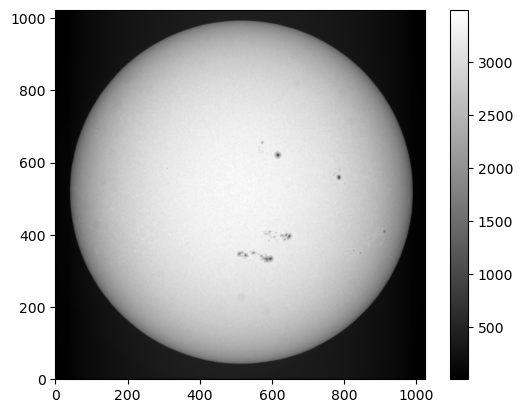

In [8]:
import fitsio

fits_image_file = fitsio.FITS(fits_image_file_name)
fits_image_file.update_hdu_list()
images = [hdu for hdu in fits_image_file.hdu_list
          if hdu.has_data() and hdu.get_info()['hdutype'] == fitsio.IMAGE_HDU]
assert(len(images) == 1)
raw_image = images[0].read()

# The image database contains images of two different sizes (1024x1024
# and 2048x2048) and of different resolutions (12 bit and 15 bit per
# pixel). We normalize to 1024x1024 and 12 bit.
#
# Note that the proper test for a 15 bit image would use the bit
# mask 0x7000 rather than 0x1000, which tests only the 13th bit.
# We prefer not to fix this bug, which is unlikely to make a
# difference. We have the same code in the workflow you will
# study later, whose precomputed results we want to remain
# reproducible.

bits_used = np.bitwise_or.reduce(raw_image.flat)
if np.bitwise_and(bits_used, 0x1000) != 0:
    raw_image = np.right_shift(raw_image, 3)
    bits_used = np.bitwise_or.reduce(raw_image.flat)
if np.bitwise_and(bits_used, 0x1000) != 0:
    print("Image ", input_file_name, " uses more than 12 bits/pixel")
    raise ValueError()

if raw_image.shape == (2048, 2048):
    raw_image.shape = (1024, 2, 1024, 2)
    raw_image = np.right_shift(raw_image.sum(1).sum(2), 2)
if raw_image.shape != (1024, 1024):
    print("Image size for ", fits_image_file_name, ": ", raw_image.shape)
    raise ValueError()

fits_header = images[0].read_header()
print("Observation date: ", fits_header['DATE-OBS'])

show_image(raw_image, 'raw_image')

## Locating the solar disk

We must restrict the search for sunspots to the solar disk itself, to avoid picking up noise from the background. We even exclude the darkest parts of the outer rim (called the limb in astro-jargon) to avoid false positives.

Our strategy for finding the solar disk, minus the limb, is to project the image on the x and y axes via a maximum operation, and then look for the intervals along these axes that exceed a threshold chosen, after manual inspection of many images, at 750. The maximum projection eliminates small dark areas, such as sunspots. We take the edges of the solar disk to be the first point from the left and right (or top and bottom) whose intensity exceeds the threshold. The center of the disk is then given by the centers of the x and y intervals, and the diameter is taken to be the average of the two interval widths.

First, we take a look at the maximum projections, to convince us that our threshold choice is reasonable. Note that the y axis corresponds to the first dimension of the image array.

In [11]:
solar_disk_threshold = 750

'outputs/projections.png'

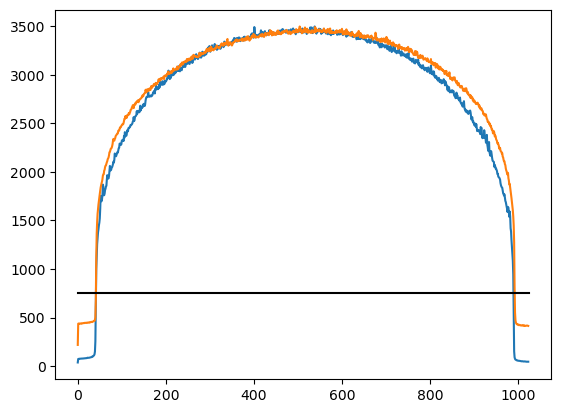

In [12]:
x_projection = raw_image.max(axis=0)
y_projection = raw_image.max(axis=1)
intensity_cross_sections([x_projection, y_projection],
                         'projections',
                        threshold=solar_disk_threshold)

Applying the threshold yields a binary mask:

'outputs/projection-masks.png'

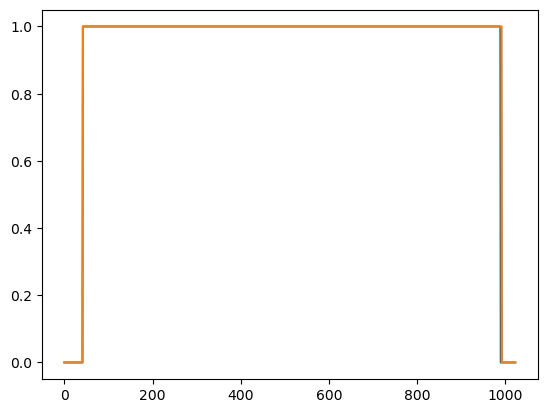

In [13]:
x_mask = x_projection > solar_disk_threshold
y_mask = y_projection > solar_disk_threshold
intensity_cross_sections([x_mask, y_mask], 'projection-masks')

We take all pixels above the threshold to be inside the solar
disk. We can then compute its center as the centroid of the surface
defined by these pixels, and the radius from the radius of gyration
of the disk.

In [14]:
temp_solar_disk_mask = (raw_image >= solar_disk_threshold).astype(np.uint8)
temp_solar_disk_pixel_count = np.sum(temp_solar_disk_mask)
x_indices = np.arange(raw_image.shape[1])[np.newaxis, :]
y_indices = np.arange(raw_image.shape[0])[:, np.newaxis]
x_center = np.sum(temp_solar_disk_mask * x_indices) / temp_solar_disk_pixel_count
y_center = np.sum(temp_solar_disk_mask * y_indices) / temp_solar_disk_pixel_count
radial_distance_sq = temp_solar_disk_mask * ((x_indices-x_center)**2 + (y_indices-y_center)**2)
radius = np.sqrt(2.*np.sum(radial_distance_sq) / temp_solar_disk_pixel_count)
(x_center,y_center, radius)

(515.4490211501609, 516.6435907683226, 474.76799544787644)

Some functions used later require integer parameters for the solar disk.

In [15]:
x_center = int(round(x_center))
y_center = int(round(y_center))
radius = int(round(radius))
(x_center,y_center, radius)

(515, 517, 475)

We make a new perfectly circular mask from the center and radius,
plus a new solar disk image in which all background pixles are set
to zero. We reduce the radius a bit in order to avoid noise (due to
low contrast) near the edge.

In [16]:
radius_scale_factor = 0.95

import skimage.draw
solar_disk_mask = np.zeros(raw_image.shape, dtype=np.uint8)
yy, xx = skimage.draw.disk((y_center, x_center), radius_scale_factor*radius, shape=solar_disk_mask.shape)
solar_disk_mask[yy, xx] = 1
solar_disk = solar_disk_mask*raw_image

'outputs/solar-disk-mask.png'

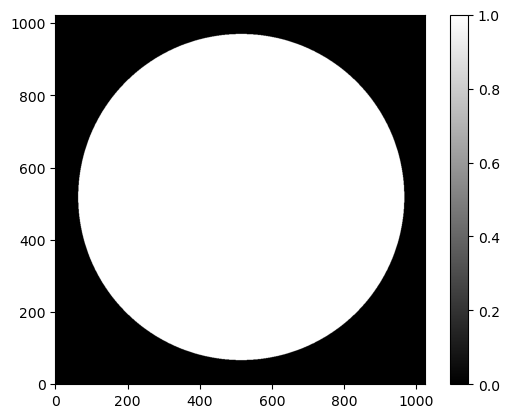

In [17]:
show_image(solar_disk_mask, 'solar-disk-mask')

## Modelling the solar intensity profile

The intensity of the solar disk decreases from the center outwards,
due to a geometric effect called limb darkening (see
https://en.wikipedia.org/wiki/Limb_darkening). The resulting
intensity variation makes it more difficult to identify the
variation due to sunspots, which happens on a much smaller length
scale. Therefore we fit a simple model for limb darkening to the
observed image, and look for sunspots in the difference between the
image and the model. We follow the derivation in the Wikipedia
article cited above, using a model of order N=2.

In [18]:
radial_distance = np.sqrt(solar_disk_mask * ((x_indices-x_center)**2 + (y_indices-y_center)**2))
rho = radial_distance / radius
one_minus_cos_psi = solar_disk_mask - np.sqrt(solar_disk_mask*(1-rho**2))

def model(parameters):
    I_0, A_1, A_2 = parameters
    m = I_0 * solar_disk_mask * (1 + one_minus_cos_psi*(A_1 + one_minus_cos_psi*A_2))
    # The model can have negative values for certain input parameters,
    # which in turn can occur when called by optimization algorithms.
    return np.maximum(0., m)

As starting values for the parameters, we take the intensity maximum
from the image for I_0, and the values for A_1 and A_2 given
in the Wikipedia article.

In [19]:
I_0 = solar_disk.max()
A_1 = -0.47
A_2 = -0.23

For improving these parameters, we define a cost function as the
squared difference of twice the square root of the observations and
twice the square root of the prediction, computed over a reduces
solar disk because of the smaller intensities, and thus larger
noise, on the outer limb region.

In [20]:
sqrt_solar_disk = np.sqrt(solar_disk)
def residuals(parameters):
    return 2 * (sqrt_solar_disk - np.sqrt(model(parameters)))

cost_mask = solar_disk_mask * (rho <= 0.9).astype(np.int8)
pixels_in_cost_mask = cost_mask.sum()
def cost(parameters):
    diff = cost_mask * residuals(parameters)
    return np.sum(diff**2)/pixels_in_cost_mask

We use an off-the-shelf optimization algorithm, Nelder-Wead.

In [21]:
from scipy.optimize import minimize
fit = minimize(cost, [I_0, A_1, A_2], method='Nelder-Mead',
               options={'disp': False, 'return_all': True, 'maxiter': 1000})
final_parameters = [fit.x[0], fit.x[1], fit.x[2]]
final_cost = fit.fun
fitted_solar_disk_model = model(final_parameters)

Print the model parameters and cost before and after the fit.

In [22]:
print("Solar disk (x, y), r: (%d, %d), %d" % (x_center, y_center, radius))
print("Initial parameters: %f, %f, %f" % (I_0, A_1, A_2))
print("Initial cost: %f" % cost([I_0, A_1, A_2]))
print("Final parameters: %f, %f, %f" % tuple(final_parameters))
print("Final cost: %f" % final_cost)

Solar disk (x, y), r: (515, 517), 475
Initial parameters: 3499.000000, -0.470000, -0.230000
Initial cost: 8.400895
Final parameters: 3356.119618, -0.495690, -0.181566
Final cost: 2.610158


Plot the fitted model in comparison with the observed intensity profiles.

'outputs/cross-section-x.png'

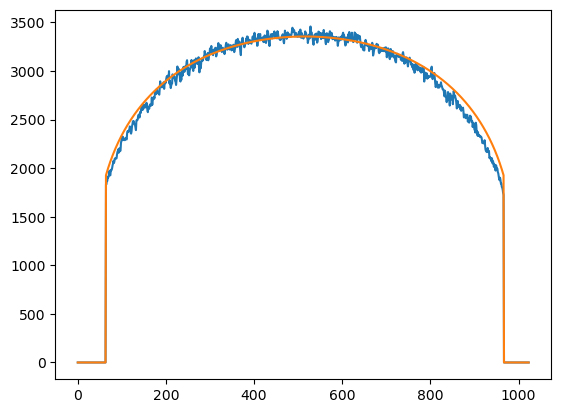

In [23]:
intensity_cross_sections([solar_disk[int(y_center), :],
                          fitted_solar_disk_model[int(y_center), :]],
                          'cross-section-x')

'outputs/cross-section-y.png'

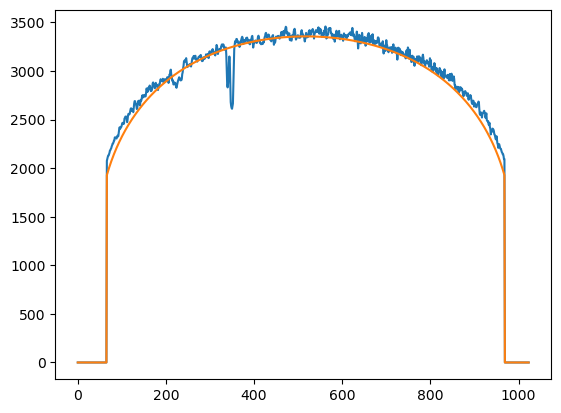

In [24]:
intensity_cross_sections([solar_disk[:, int(x_center)],
                          fitted_solar_disk_model[:, int(x_center)]],
                          'cross-section-y')

The fitted model describes the intensity variation due to the
geometry of the observation. It's the residuals of the fit that we
are interested in, because that's where the sunspots are. We
construct an image from the residuals, which is slightly reduced in
size (-5% in the radius) because of the imprecisions in the edge of
the disk resulting from the previous steps.

'outputs/residual-cross-section.png'

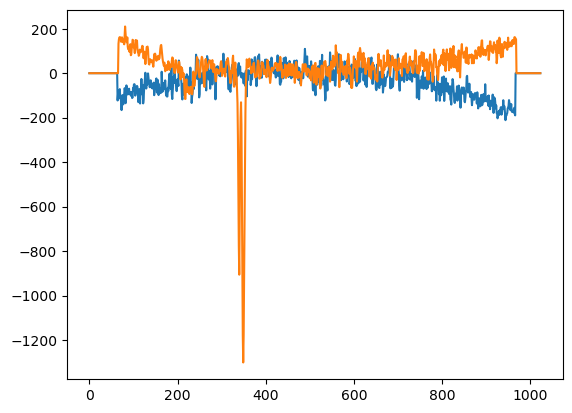

In [25]:
residual_disk_mask = solar_disk_mask * (rho <= 0.95).astype(np.int8)
residual_disk = residual_disk_mask * (solar_disk - fitted_solar_disk_model)
intensity_cross_sections([residual_disk[int(x_center), :],
                          residual_disk[:, int(y_center)]],
                         'residual-cross-section')

'outputs/residual-disk.png'

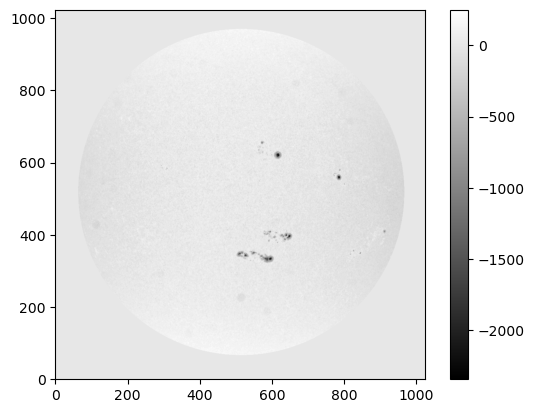

In [26]:
show_image(residual_disk, 'residual-disk')

## Find sunspots

The "black tophat" transform highlights dark objects in an image
while removing intensity variation in the image background. This
requires a specification of how to distinguish dark objects from
darker zones of the background. This specification takes the form of
a "structure element". We use a disk whose radius is 10% of the
solar disk, thus assuming that sunspots are smaller than this. The
blackhat transform inverts the sunspots' intensities, showing them
as bright spots on a black background. In addition to this image, we
show its intensity profiles with the threshold used in the following
for defining sunspots. Warning: its choice is highly arbitrary.

'outputs/tophat.png'

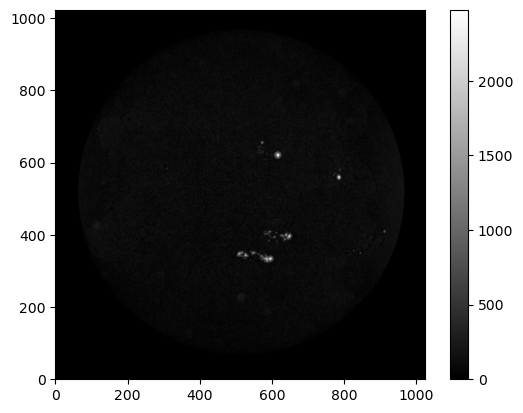

In [27]:
import skimage.morphology

circle = skimage.morphology.disk(radius // 10)
tophat = residual_disk_mask * skimage.morphology.black_tophat(residual_disk, circle)
show_image(tophat, 'tophat')

'outputs/sunspot-threshold.png'

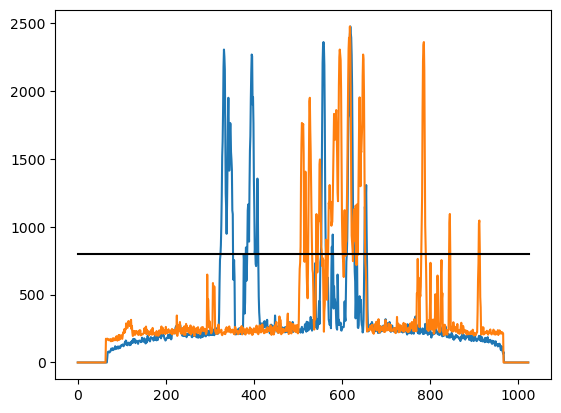

In [28]:
threshold = 800
intensity_cross_sections([tophat.max(axis=1), tophat.max(axis=0)],
                         'sunspot-threshold', threshold=threshold)

We use a measuring function that analyzes zones about that threshold
and groups them into contiguous regions, corresponding (ideally) to
individual sunspots.

In [29]:
import skimage.measure

peaks = tophat > threshold
sunspot_labels = skimage.measure.label(peaks)
regions = skimage.measure.regionprops_table(
                sunspot_labels, solar_disk,
                properties=["label", "centroid", "area", "min_intensity"])
nspots = len(regions['label'])
for i in range(nspots):
    print("Sunspot %d, area %d px" % (regions['label'][i], regions['area'][i]))
    print("Centroid: (%f, %f)" % (regions['centroid-1'][i], regions['centroid-0'][i]))
    print()

Sunspot 1, area 255 px
Centroid: (588.992157, 332.082353)

Sunspot 2, area 2 px
Centroid: (576.000000, 330.500000)

Sunspot 3, area 58 px
Centroid: (527.448276, 342.258621)

Sunspot 4, area 12 px
Centroid: (570.666667, 339.666667)

Sunspot 5, area 3 px
Centroid: (516.666667, 339.666667)

Sunspot 6, area 57 px
Centroid: (509.807018, 345.719298)

Sunspot 7, area 1 px
Centroid: (573.000000, 342.000000)

Sunspot 8, area 35 px
Centroid: (549.228571, 348.542857)

Sunspot 9, area 18 px
Centroid: (517.333333, 348.833333)

Sunspot 10, area 4 px
Centroid: (844.500000, 348.000000)

Sunspot 11, area 3 px
Centroid: (542.333333, 351.666667)

Sunspot 12, area 1 px
Centroid: (591.000000, 382.000000)

Sunspot 13, area 5 px
Centroid: (637.400000, 386.200000)

Sunspot 14, area 6 px
Centroid: (634.500000, 387.000000)

Sunspot 15, area 85 px
Centroid: (647.435294, 393.847059)

Sunspot 16, area 6 px
Centroid: (605.833333, 392.166667)

Sunspot 17, area 10 px
Centroid: (631.200000, 394.300000)

Sunspot 18, ar

The following image shows the sunspots as a binary mask, for clarity:

'outputs/peaks.png'

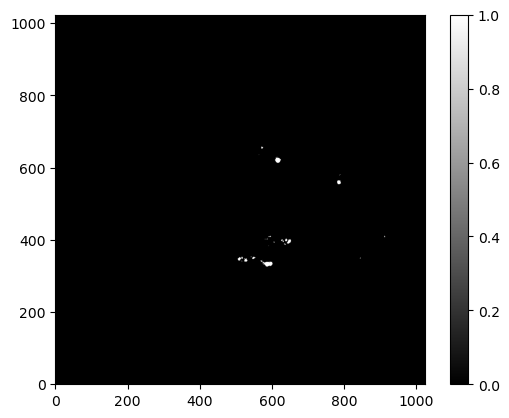

In [30]:
show_image(peaks, 'peaks')

Finally, we go back to the initial image, on top of which we put a marker (red circle) for each sunspot:

'outputs/sunspots.png'

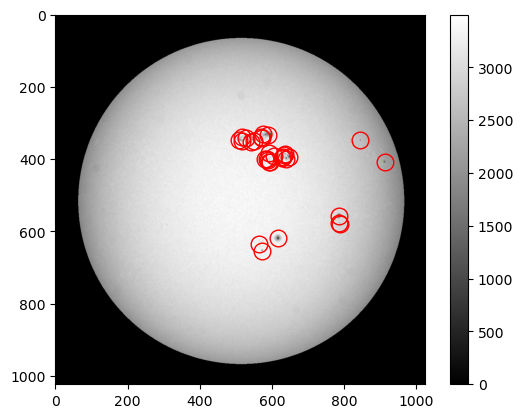

In [31]:
filename = os.path.join('outputs/sunspots.png')
plt.clf()
plt.imshow(solar_disk, cmap='gray')
plt.colorbar()
for i in range(nspots):
    plt.plot(regions['centroid-1'][i],
             regions['centroid-0'][i],
             marker = 'o', markeredgecolor='r', markerfacecolor='none', markersize=12)
plt.savefig(filename)
filename

## The drawing for the same day
For comparison, here is the drawing made by an astronomer trained in sunspot classification according to the rules established in the 19th century. The drawing is based on an observation made the same day and in the same place (Brussels) as the image we have been analyzing above. The observer identified 61 sunspots, almost twice as many as our automated analysis.

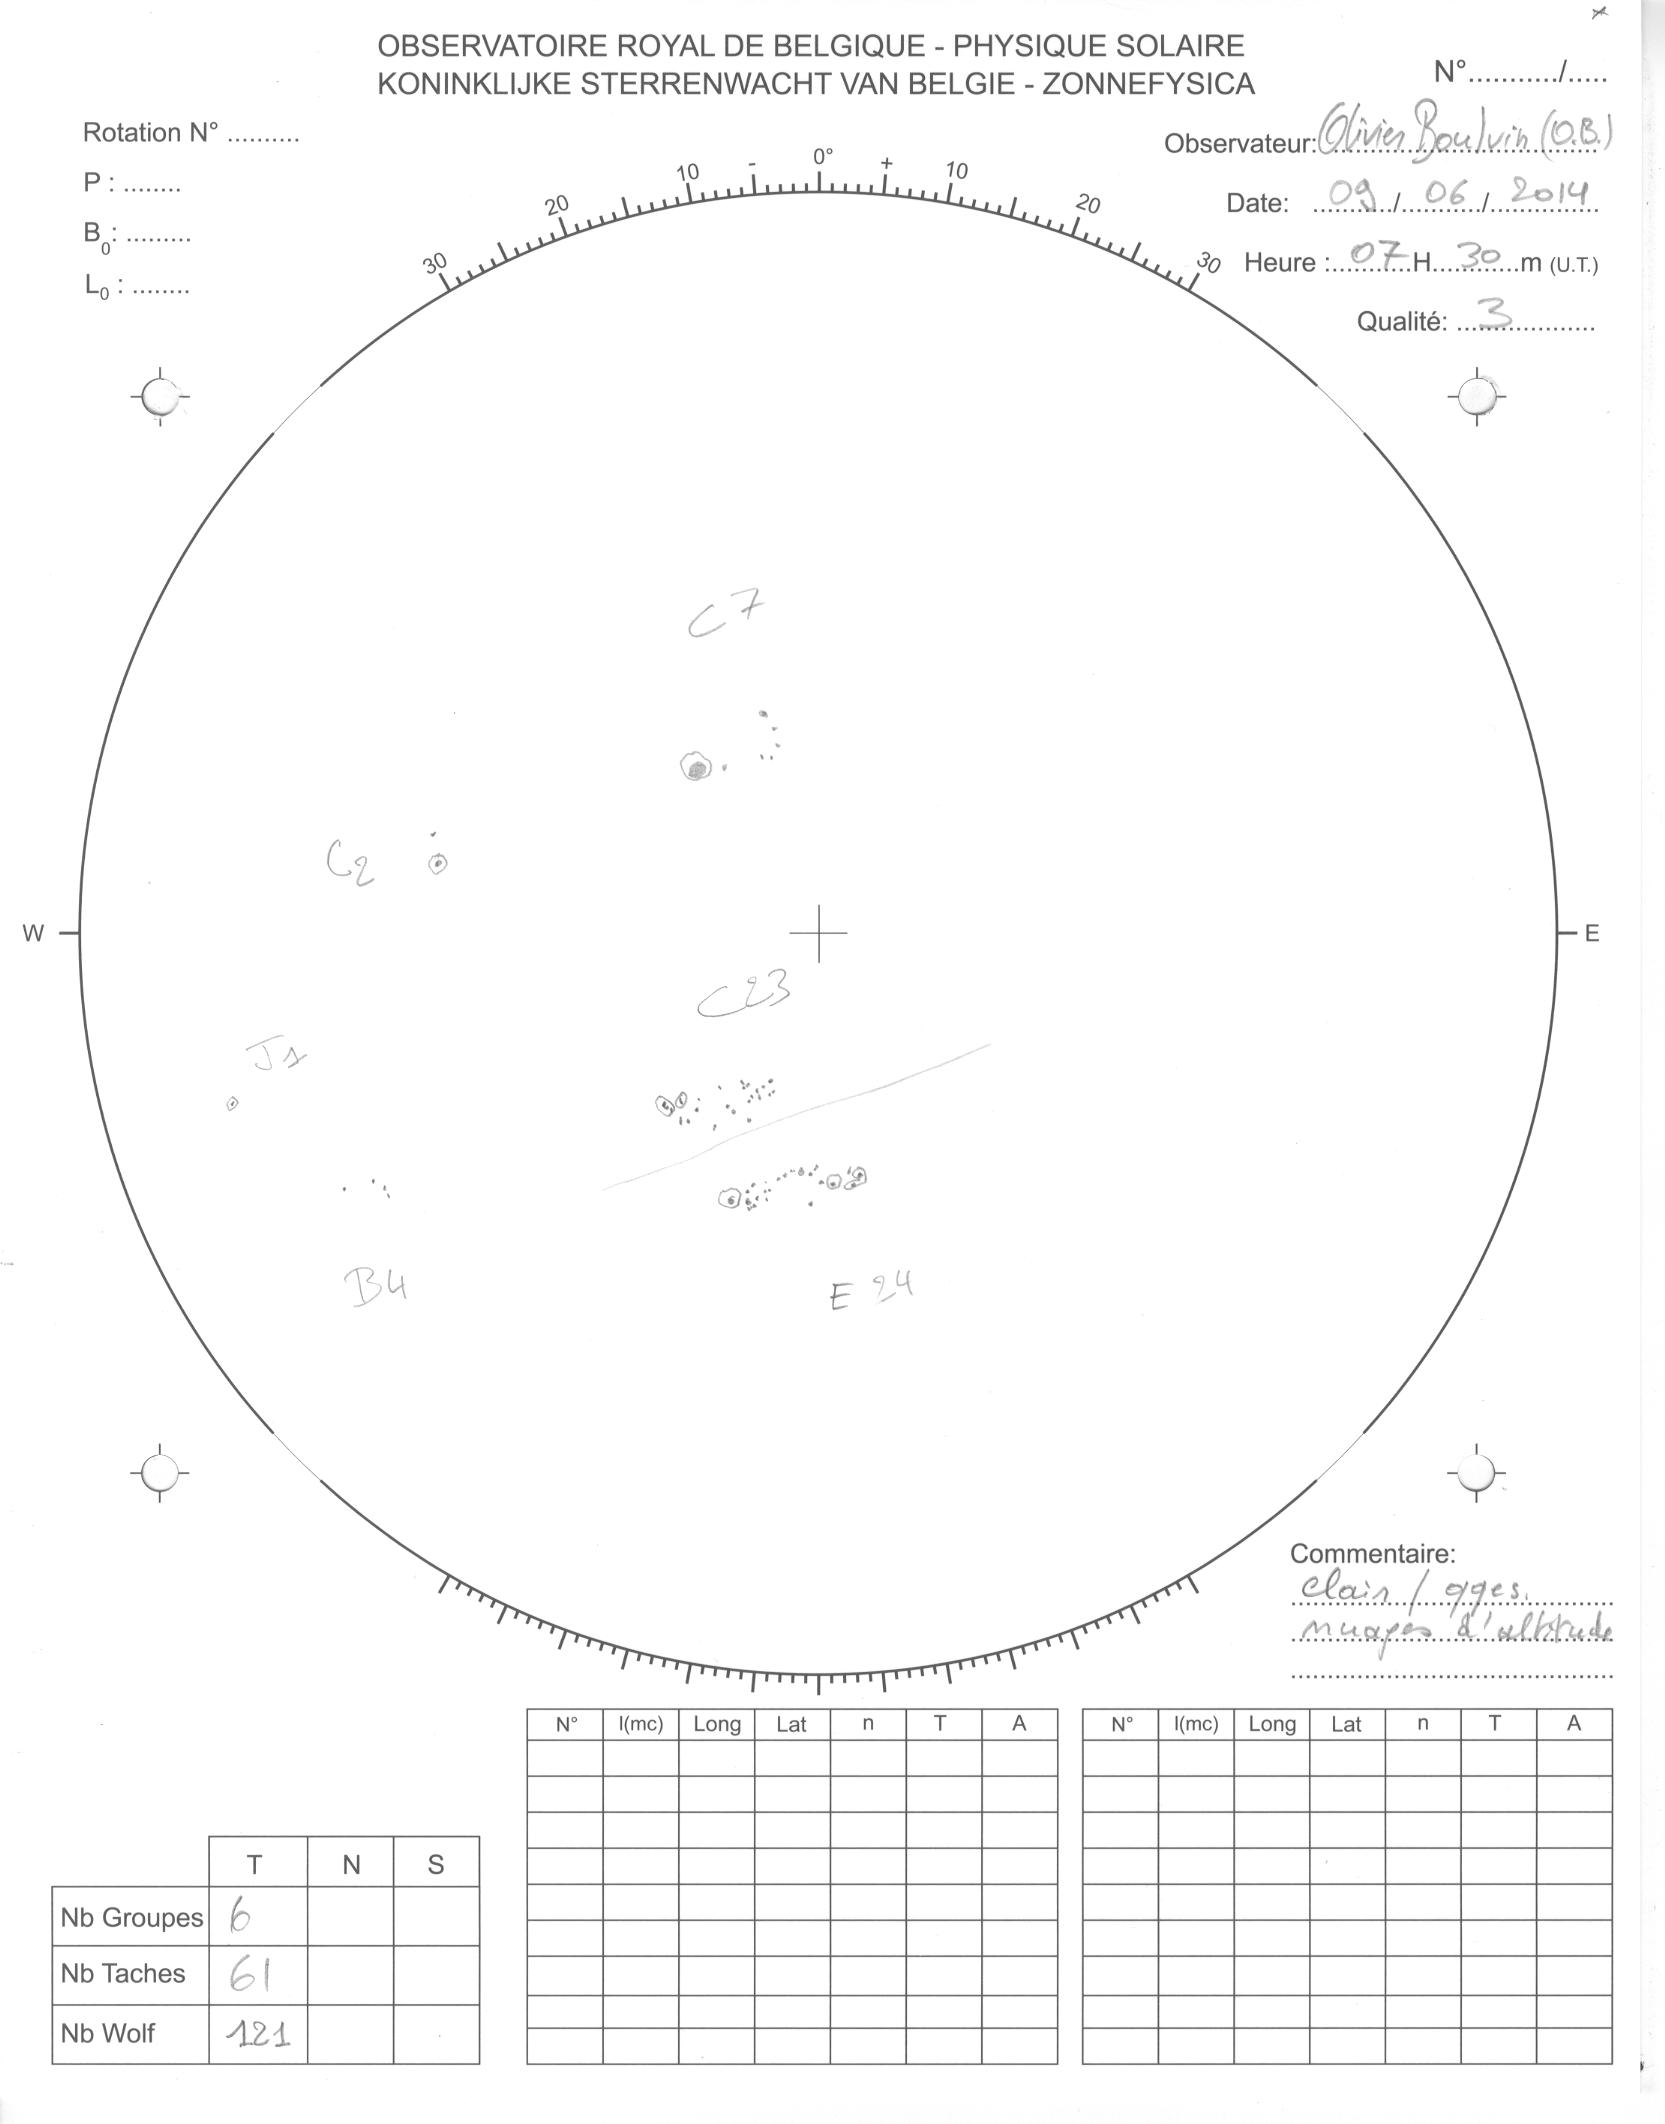

In [32]:
from IPython.display import Image, display
display(Image(filename=drawing_file_name, width=600))